# Preprocesamiento de texto

> Cómo pasar de texto en bruto a unidades con las que se puede contar y modelar: limpieza, tokenización, normalización, etiquetado gramatical (PoS), lematización y *stemming*, y palabras vacías, con spaCy y NLTK sobre reseñas de Yelp. Cerramos con la ley de Zipf, que explica por qué el vocabulario de un corpus es tan desigual. Con los errores típicos: quitar las negaciones junto con las palabras vacías, unir todos los documentos en uno, poner en minúsculas antes de etiquetar o lematizar sin la categoría gramatical.
>
> **Requisitos previos:** [Limpieza de datos](../03-preparacion-datos/02-limpieza-datos.ipynb) · **Relacionado:** [N-gramas y colocaciones](02-n-gramas-y-colocaciones.ipynb) · [Representación vectorial y TF-IDF](03-representacion-vectorial-tfidf.ipynb) · [Modelos de lenguaje preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb)

## 1. Idea clave

Un modelo no entiende cadenas de caracteres: necesita **unidades discretas** (palabras, lemas, subpalabras) que pueda contar, comparar o convertir en vectores. El **preprocesamiento** es la cadena de pasos que lleva del texto en bruto a esas unidades: limpiar el ruido del formato, cortar el texto en *tokens*, normalizarlos (minúsculas, lemas) y, según la tarea, descartar las palabras que no aportan.

No hay una cadena única: cada paso **reduce el vocabulario** (menos dispersión, modelos más pequeños) pero también **pierde información** (mayúsculas, tiempos verbales, negaciones). Los métodos clásicos ([n-gramas](02-n-gramas-y-colocaciones.ipynb), [TF-IDF](03-representacion-vectorial-tfidf.ipynb), [temas](05-deteccion-de-temas.ipynb)) dependen mucho de estas decisiones; los [modelos preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb) traen su propio tokenizador y casi no necesitan preprocesamiento, solo limpieza.

## 2. Conceptos importantes

### 2.1. La cadena de preprocesamiento

$$
\text{texto en bruto}\;\rightarrow\;\text{limpieza}\;\rightarrow\;\text{tokenización}\;\rightarrow\;\text{normalización}\;\rightarrow\;\text{etiquetado PoS}\;\rightarrow\;\text{lematización / stemming}\;\rightarrow\;\text{filtrado de palabras vacías}
$$

- **Limpieza**: quitar lo que no es lenguaje (etiquetas HTML, URL, saltos de línea escapados, entidades como `&amp;`).
- **Tokenización** (*tokenization*): cortar el texto en *tokens*. Partir por espacios no basta: la puntuación va pegada (`great!`), hay contracciones (`can't` → `ca` + `n't`), abreviaturas (`U.S.`), precios (`$12.50`) o emoticonos (`:)`). Los tokenizadores de NLTK y spaCy usan reglas y excepciones para cada idioma. La **segmentación en oraciones** (*sentence splitting*) es el mismo problema un nivel por encima.
- **Normalización**: hacer iguales formas que queremos tratar como iguales: minúsculas (*case folding*), Unicode, contracciones.
- **Etiquetado gramatical** (PoS, *part-of-speech tagging*): asignar a cada *token* su categoría (nombre, verbo, adjetivo…) según el contexto. Hay dos juegos de etiquetas habituales: el del Penn Treebank (`NN`, `NNS`, `VBD`, `JJ`…, 36 etiquetas, solo inglés) y el de **Universal Dependencies** (`NOUN`, `VERB`, `ADJ`…, 17 etiquetas comunes a todos los idiomas).

### 2.2. Tokens, tipos y vocabulario

Un **token** es cada aparición de una unidad en el texto; un **tipo** (*type*) es cada unidad distinta. En «*the food and the service*» hay 5 tokens y 4 tipos. El conjunto de tipos es el **vocabulario** $V$ y su tamaño $|V|$ decide cuántas columnas tendrá una [bolsa de palabras](03-representacion-vectorial-tfidf.ipynb): cada paso de normalización busca reducir $|V|$ sin perder lo importante.

### 2.3. Stemming y lematización

Ambos reducen las formas flexionadas (*studies*, *studying*, *studied*) a una forma común:

- El ***stemming*** recorta sufijos con reglas, sin diccionario ni contexto: *studies* → `studi`. Es rápido, pero el resultado no siempre es una palabra y comete errores en los dos sentidos: junta palabras distintas (*university* y *universe* → `univers`) y separa formas de la misma (*ran* no se convierte en `run`). Los más usados son **Porter** (1980) y su revisión **Snowball** («Porter2»), que además tiene versiones para otros idiomas.
- La **lematización** (*lemmatization*) devuelve el **lema**, la forma de diccionario: *studies* → `study`, *better* → `good`, *was* → `be`. Necesita un diccionario (WordNet en NLTK, tablas y reglas en spaCy) y **la categoría gramatical**: *meeting* es `meeting` como nombre y `meet` como verbo.

### 2.4. Palabras vacías

Las **palabras vacías** (*stop words*) son las muy frecuentes y con poco contenido propio: artículos, preposiciones, pronombres, auxiliares. Quitarlas reduce mucho el número de tokens y deja a la vista las palabras de contenido. Pero las listas son **genéricas**: incluyen negaciones (*not*, *no*, *never*) e intensificadores (*very*, *too*) que en análisis de sentimientos cambian el significado, y no incluyen las palabras vacías **del dominio** (en reseñas, *place*, *get*, *go*).

### 2.5. Ley de Zipf

En cualquier corpus de lenguaje natural, si se ordenan las palabras por frecuencia, la frecuencia $f(r)$ de la palabra con **rango** $r$ (la más frecuente tiene $r=1$) es aproximadamente

$$
f(r)\approx\frac{C}{r^{\alpha}}\quad\Longleftrightarrow\quad \log f(r)\approx\log C-\alpha\log r,
$$

con $C$ una constante que depende del tamaño del corpus y $\alpha\approx 1$. En escala log-log es una **recta de pendiente $-\alpha$**: la segunda palabra aparece la mitad que la primera, la décima, una décima parte. Dos consecuencias prácticas:

- **Pocas palabras cubren casi todo el texto**: las primeras cien (casi todas palabras vacías) suman alrededor de la mitad de los tokens.
- **La mayoría de los tipos son raros**: muchos aparecen una sola vez (*hapax legomena*). Por eso los vocabularios se recortan con una frecuencia mínima y por eso siempre aparecerán palabras desconocidas en datos nuevos.

## 3. Código

Usamos **Yelp Review Full**: reseñas de negocios de Yelp (restaurantes, talleres, peluquerías…) en inglés, etiquetadas con su número de estrellas (de 1 a 5, codificadas de 0 a 4). Es la versión preparada por Zhang, Zhao y LeCun (2015) a partir del *Yelp Dataset Challenge*: 650 000 reseñas de entrenamiento y 50 000 de prueba, equilibradas por estrellas. Para estos apuntes basta el conjunto de prueba (50 000 reseñas, unos 23 MB), que se descarga una vez de Hugging Face y se guarda en `data/`.

El procesamiento lingüístico se hace con **spaCy** (modelo `en_core_web_sm`, se instala como un paquete de Python) y, para comparar, con **NLTK**.

In [1]:
import contextlib
import html
import io
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import spacy
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from huggingface_hub.utils import logging as hf_logging
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="NLTK will not authorize")   # aviso de permisos del directorio de NLTK
for recurso in ["punkt_tab", "averaged_perceptron_tagger_eng", "wordnet", "stopwords"]:
    nltk.download(recurso, quiet=True)                    # recursos de NLTK (solo la primera vez)

nlp = spacy.load("en_core_web_sm")                         # tokenizador, etiquetador PoS, lematizador, parser y NER
print("Componentes de spaCy:", nlp.pipe_names)

Componentes de spaCy: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    yelp = load_dataset(
        "Yelp/yelp_review_full",
        data_files={"test": "yelp_review_full/test-00000-of-00001.parquet"},   # solo el conjunto de prueba
        split="test",
        cache_dir="data",
        verification_mode="no_checks",                     # no exige descargar también el de entrenamiento
    )

reviews = yelp.to_pandas()
reviews["stars"] = reviews["label"] + 1
print(reviews.shape)
print(reviews["stars"].value_counts().sort_index().to_dict())
reviews[["stars", "text"]].head(3)

(50000, 3)
{1: 10000, 2: 10000, 3: 10000, 4: 10000, 5: 10000}


,stars,text
0,1,I got 'new' tires from them and within two wee...
1,1,Don't waste your time. We had two different p...
2,1,All I can say is the worst! We were the only 2...


### 3.1. Limpieza

Antes de tokenizar conviene mirar qué ruido trae el texto. En este corpus, los saltos de línea aparecen **escapados** (la secuencia de dos caracteres `\n`, no un salto real), las comillas como `\"` y hay algunas URL y entidades HTML. Si no se limpian, el tokenizador produce *tokens* como `\n\nOur` que no son palabras. Para más detalle sobre limpieza de datos en general, ver [limpieza de datos](../03-preparacion-datos/02-limpieza-datos.ipynb).

In [3]:
patterns = {
    "salto de línea escapado (\\n)": r"\\n",
    "comillas escapadas (\\\")": r'\\"',
    "URL": r"https?://\S+|www\.\S+",
    "entidad HTML (&amp; ...)": r"&[a-z]+;|&#\d+;",
}
print("Reseñas afectadas:")
for name, pattern in patterns.items():
    print(f"  {name:<30} {reviews['text'].str.contains(pattern).sum():>6,}")

def clean(text):
    text = text.replace("\\n", " ").replace('\\"', '"')    # secuencias escapadas
    text = html.unescape(text)                              # &amp; -> &
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URL
    return re.sub(r"\s+", " ", text).strip()                # espacios repetidos

reviews["clean"] = reviews["text"].map(clean)
example = reviews.loc[reviews["text"].str.contains(r"\\n"), "text"].iloc[0]
pos = example.index("\\n")
print("\nAntes:  ", example[pos - 40:pos + 40])
print("Después:", clean(example)[pos - 40:pos + 38])

Reseñas afectadas:
  salto de línea escapado (\n)   25,130
  comillas escapadas (\")         9,047
  URL                               226
  entidad HTML (&amp; ...)            2



Antes:   ed? This was supposed to be a new tire. \nI took the tire over to Flynn's and th
Después: ed? This was supposed to be a new tire. I took the tire over to Flynn's and th


La limpieza **no** pone el texto en minúsculas ni quita la puntuación: el etiquetador PoS y el segmentador de oraciones usan las mayúsculas y los signos, así que esas normalizaciones van después (ver la sección 4).

### 3.2. Tokenización

Comparamos cuatro formas de tokenizar una frase con los casos difíciles típicos: contracciones, abreviaturas, precios, puntuación repetida, guiones, una URL y un emoticono.

In [4]:
sentence = "I can't believe the U.S. menu costs $12.50!! The fish-and-chips were great :) www.example.com"

tokenizers = {
    "str.split()": sentence.split(),
    r"regex \w+": re.findall(r"\w+", sentence),
    "NLTK word_tokenize": nltk.word_tokenize(sentence),
    "spaCy": [t.text for t in nlp.tokenizer(sentence)],
}
for name, toks in tokenizers.items():
    print(f"{name:<19} ({len(toks):>2}): {toks}")

str.split()         (14): ['I', "can't", 'believe', 'the', 'U.S.', 'menu', 'costs', '$12.50!!', 'The', 'fish-and-chips', 'were', 'great', ':)', 'www.example.com']
regex \w+           (20): ['I', 'can', 't', 'believe', 'the', 'U', 'S', 'menu', 'costs', '12', '50', 'The', 'fish', 'and', 'chips', 'were', 'great', 'www', 'example', 'com']
NLTK word_tokenize  (19): ['I', 'ca', "n't", 'believe', 'the', 'U.S.', 'menu', 'costs', '$', '12.50', '!', '!', 'The', 'fish-and-chips', 'were', 'great', ':', ')', 'www.example.com']
spaCy               (22): ['I', 'ca', "n't", 'believe', 'the', 'U.S.', 'menu', 'costs', '$', '12.50', '!', '!', 'The', 'fish', '-', 'and', '-', 'chips', 'were', 'great', ':)', 'www.example.com']


- `split()` deja la puntuación pegada (`$12.50!!`): `great` y `great!` serían tipos distintos.
- La expresión regular `\w+` rompe todo lo que no sea alfanumérico: pierde `$`, parte `can't` en `can` + `t`, `U.S.` en `U` + `S`, `12.50` en dos números y la URL en trozos.
- NLTK (reglas del Penn Treebank) separa la contracción en `ca` + `n't` (así *not* y *n't* quedan como palabras sueltas), separa `$` y los signos, conserva `U.S.`, `12.50`, `fish-and-chips` y la URL, pero rompe el emoticono en `:` + `)`.
- spaCy usa reglas y **excepciones** por idioma: coincide con NLTK en casi todo, mantiene junto el emoticono `:)` (tiene patrones para ellos) y separa los guiones de `fish-and-chips`.

Ningún tokenizador es «el correcto»; lo importante es usar **el mismo** al entrenar y al aplicar el modelo, y revisar qué hace con los casos que importan en el dominio.

### 3.3. Etiquetado gramatical (PoS)

spaCy procesa el texto completo con `nlp(texto)` y cada *token* trae su categoría universal (`pos_`), la detallada del Penn Treebank (`tag_`), su lema (`lemma_`) y si es palabra vacía (`is_stop`). NLTK etiqueta con `pos_tag`, que usa las etiquetas del Penn Treebank.

In [5]:
text = "The owners were meeting us after the meetings, but the wings were better than last time."
doc = nlp(text)
nltk_tags = nltk.pos_tag([t.text for t in doc])           # mismos tokens que spaCy, para comparar

pos_table = pd.DataFrame({
    "token": [t.text for t in doc],
    "spaCy pos_": [t.pos_ for t in doc],
    "spaCy tag_": [t.tag_ for t in doc],
    "NLTK pos_tag": [tag for _, tag in nltk_tags],
    "lemma_": [t.lemma_ for t in doc],
    "is_stop": [t.is_stop for t in doc],
})
pos_table.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
token,The,owners,were,meeting,us,after,the,meetings,",",but,the,wings,were,better,than,last,time,.
spaCy pos_,DET,NOUN,AUX,VERB,PRON,ADP,DET,NOUN,PUNCT,CCONJ,DET,NOUN,AUX,ADJ,ADP,ADJ,NOUN,PUNCT
spaCy tag_,DT,NNS,VBD,VBG,PRP,IN,DT,NNS,",",CC,DT,NNS,VBD,JJR,IN,JJ,NN,.
NLTK pos_tag,DT,NNS,VBD,VBG,PRP,IN,DT,NNS,",",CC,DT,NNS,VBD,JJR,IN,JJ,NN,.
lemma_,the,owner,be,meet,we,after,the,meeting,",",but,the,wing,be,well,than,last,time,.
is_stop,True,False,True,False,True,True,True,False,False,True,True,False,True,False,True,True,False,False


El etiquetador decide por el contexto: el mismo *meeting* es verbo en *were meeting* (`VERB`, `VBG`) y nombre en *the meetings* (`NOUN`, `NNS`), y por eso su lema cambia (`meet` frente a `meeting`). spaCy y NLTK coinciden aquí en las etiquetas del Penn Treebank; spaCy añade la universal, más útil para filtrar (por ejemplo, quedarse solo con `NOUN` y `ADJ` para buscar aspectos de un producto).

### 3.4. Stemming frente a lematización

Comparamos dos *stemmers* (Porter y Snowball) con el lematizador de WordNet de NLTK **sin** y **con** la categoría gramatical, y con el lema de spaCy. Para darle a WordNet la categoría hay que traducir la etiqueta universal (`NOUN`, `VERB`, `ADJ`, `ADV`) a la suya (`n`, `v`, `a`, `r`).

In [6]:
porter, snowball = PorterStemmer(), SnowballStemmer("english")
wordnet = WordNetLemmatizer()
UPOS_TO_WN = {"NOUN": "n", "VERB": "v", "AUX": "v", "ADJ": "a", "ADV": "r"}

doc = nlp("She was studying the studies of universities and the universe, "
          "and her better feet ran happily through the meetings")
rows = []
for t in doc:
    if not t.is_alpha or t.is_stop:
        continue
    rows.append({
        "token": t.text,
        "PoS": t.pos_,
        "Porter": porter.stem(t.text),
        "Snowball": snowball.stem(t.text),
        "WordNet (sin PoS)": wordnet.lemmatize(t.text.lower()),                     # por defecto, nombre
        "WordNet (con PoS)": wordnet.lemmatize(t.text.lower(), UPOS_TO_WN.get(t.pos_, "n")),
        "spaCy": t.lemma_,
    })
pd.DataFrame(rows).set_index("token")

,PoS,Porter,Snowball,WordNet (sin PoS),WordNet (con PoS),spaCy
token,,,,,,
studying,VERB,studi,studi,studying,study,study
studies,NOUN,studi,studi,study,study,study
universities,NOUN,univers,univers,university,university,university
universe,NOUN,univers,univers,universe,universe,universe
better,ADJ,better,better,better,good,well
feet,NOUN,feet,feet,foot,foot,foot
ran,VERB,ran,ran,ran,run,run
happily,ADV,happili,happili,happily,happily,happily
meetings,NOUN,meet,meet,meeting,meeting,meeting


- Los *stemmers* producen raíces que no son palabras (`studi`, `univers`, `happili`), juntan *universities* y *universe* en `univers` y no reducen las formas irregulares (*ran*, *feet*). En inglés, Porter y Snowball apenas se diferencian; Snowball corrige algunos casos raros de Porter.
- WordNet **sin PoS** lo trata todo como nombre: reduce *studies* y *feet*, pero deja *studying*, *ran* y *better* sin cambiar. **Con PoS** acierta en todos.
- spaCy lematiza con la categoría que asigna su etiquetador, así que acierta en casi todo sin trabajo extra. No es infalible: para el adjetivo *better* devuelve `well` (el lema del adverbio) en lugar de `good`, igual que en la tabla de la sección 3.3.
- *Meetings* muestra la diferencia de fondo: Porter la convierte en `meet` y la junta con el verbo, mientras que los lematizadores conservan el nombre `meeting`.

### 3.5. Palabras vacías

Las listas de NLTK y spaCy son distintas en tamaño y contenido. Lo importante es comprobar qué palabras útiles para la tarea están dentro.

In [7]:
nltk_stop = set(stopwords.words("english"))
spacy_stop = nlp.Defaults.stop_words
print(f"NLTK: {len(nltk_stop)} palabras · spaCy: {len(spacy_stop)} · en ambas: {len(nltk_stop & spacy_stop)}")

check = ["not", "no", "nor", "never", "n't", "very", "too", "against", "nothing", "without", "few"]
print(pd.DataFrame({"NLTK": [w in nltk_stop for w in check],
                    "spaCy": [w in spacy_stop for w in check]}, index=check).T.to_string())

for review in ["The food was not good and the service was never fast.",
               "Very nice place, nothing to complain about."]:
    kept = [t.text for t in nlp(review) if not t.is_stop and not t.is_punct]
    print(f"\n{review}\n  -> {kept}")

NLTK: 198 palabras · spaCy: 326 · en ambas: 123
        not    no   nor  never    n't  very   too  against  nothing  without   few
NLTK   True  True  True  False  False  True  True     True    False    False  True
spaCy  True  True  True   True   True  True  True     True     True     True  True

The food was not good and the service was never fast.
  -> ['food', 'good', 'service', 'fast']

Very nice place, nothing to complain about.
  -> ['nice', 'place', 'complain']


spaCy tiene una lista más amplia (326 palabras frente a 198 de NLTK) y **las dos incluyen las negaciones** *not*, *no* y *nor* y los intensificadores *very* y *too*; spaCy además *never*, *n't*, *nothing* y *without*. El resultado se ve en los ejemplos: «*the food was not good and the service was never fast*» queda en `food good service fast`, el sentido contrario, y «*nothing to complain about*» se queda en `complain`. Para tareas de opinión hay que quitar esas palabras de la lista (o no filtrar).

### 3.6. La cadena completa y su efecto en el vocabulario

Aplicamos la cadena a 2 000 reseñas con `nlp.pipe` (procesa por lotes, mucho más rápido que llamar a `nlp` en un bucle) y desactivamos los componentes que no hacen falta (`parser` y `ner`). Medimos cuántos tokens y tipos quedan tras cada paso.

In [8]:
sample = reviews.sample(2_000, random_state=42)["clean"].tolist()
docs = list(nlp.pipe(sample, disable=["parser", "ner"], batch_size=256))

steps = {
    "tokens de spaCy": lambda t: t.text,
    "minúsculas": lambda t: t.lower_,
    "solo alfabéticos": lambda t: t.lower_ if t.is_alpha else None,
    "lemas": lambda t: t.lemma_.lower() if t.is_alpha else None,
    "sin palabras vacías": lambda t: t.lemma_.lower() if t.is_alpha and not t.is_stop else None,
}
summary, units = [], {}
for name, fn in steps.items():
    units[name] = [u for d in docs for t in d if (u := fn(t)) is not None]
    summary.append({"paso": name, "tokens": len(units[name]), "tipos": len(set(units[name]))})
summary = pd.DataFrame(summary).set_index("paso")
summary["tipos (% del inicial)"] = (100 * summary["tipos"] / summary["tipos"].iloc[0]).round(1)
summary

,tokens,tipos,tipos (% del inicial)
paso,,,
tokens de spaCy,313688,17665,100.0
minúsculas,313688,14684,83.1
solo alfabéticos,267148,13603,77.0
lemas,267148,11007,62.3
sin palabras vacías,113390,10795,61.1


In [9]:
top = pd.DataFrame({
    "minúsculas": [f"{w} ({c})" for w, c in Counter(units["minúsculas"]).most_common(12)],
    "sin palabras vacías": [f"{w} ({c})" for w, c in Counter(units["sin palabras vacías"]).most_common(12)],
})
top.index = range(1, 13)
top

,minúsculas,sin palabras vacías
1,. (15974),good (1449)
2,the (13938),place (1237)
3,", (10066)",food (1197)
4,i (8490),like (1100)
5,and (8426),time (1011)
6,a (6917),order (870)
7,to (6739),come (866)
8,was (5082),service (800)
9,it (4309),great (735)
10,of (4036),go (693)


- Las **minúsculas** quitan el 17 % de los tipos (de 17 665 a 14 684), quedarse con los *tokens* alfabéticos un 6 % más, y la **lematización** es el paso que más reduce: el vocabulario queda en el 62 % del inicial.
- Quitar las **palabras vacías** apenas cambia el número de tipos (son unas pocas centenas de palabras) pero elimina el 58 % de los *tokens* (de 267 148 a 113 390): son pocas palabras que aparecen muchísimo, como predice la ley de Zipf (abajo).
- Antes del filtrado, las palabras más frecuentes son puntuación y palabras gramaticales; después, aparecen las de contenido (*food*, *service*, *great*), pero también palabras genéricas del dominio (*place*, *time*, *come*, *go*, *get*) que ninguna lista estándar quita.

### 3.7. Ley de Zipf

Para ver la ley de Zipf usamos las 50 000 reseñas. Solo hace falta el tokenizador, que se puede usar sin el resto del modelo (`nlp.tokenizer.pipe`) y procesa todo el conjunto en unos segundos. Ajustamos la recta $\log f = \log C - \alpha\log r$ por mínimos cuadrados en las 1 000 palabras más frecuentes y, por separado, en la cola (rangos 1 000 a 30 000).

In [10]:
freq = Counter(t.lower_ for d in nlp.tokenizer.pipe(reviews["clean"], batch_size=1_000) for t in d if t.is_alpha)
counts = np.array(sorted(freq.values(), reverse=True))
ranks = np.arange(1, len(counts) + 1)

fit = ranks <= 1_000
slope, intercept = np.polyfit(np.log10(ranks[fit]), np.log10(counts[fit]), 1)
tail = (ranks >= 1_000) & (ranks <= 30_000)
slope_tail = np.polyfit(np.log10(ranks[tail]), np.log10(counts[tail]), 1)[0]
coverage = np.cumsum(counts) / counts.sum()

print(f"Tokens: {counts.sum():,} · tipos: {len(counts):,}")
print(f"Pendiente ajustada: alpha = {-slope:.2f} (rangos 1-1000) · {-slope_tail:.2f} (rangos 1000-30000)")
print(f"Las 100 palabras más frecuentes cubren el {100 * coverage[99]:.1f} % de los tokens")
print(f"Tipos que aparecen una sola vez (hapax): {(counts == 1).sum():,} ({100 * (counts == 1).mean():.1f} % de los tipos)")

Tokens: 6,699,404 · tipos: 60,105
Pendiente ajustada: alpha = 1.07 (rangos 1-1000) · 1.81 (rangos 1000-30000)
Las 100 palabras más frecuentes cubren el 54.8 % de los tokens
Tipos que aparecen una sola vez (hapax): 25,095 (41.8 % de los tipos)


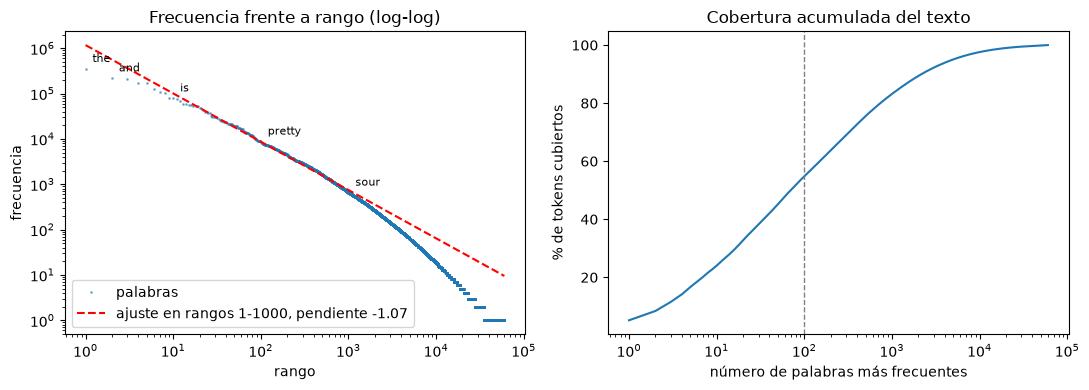

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.loglog(ranks, counts, ".", ms=2, alpha=0.5, label="palabras")
ax1.loglog(ranks, 10**intercept * ranks**slope, "r--", lw=1.5, label=f"ajuste en rangos 1-1000, pendiente {slope:.2f}")
for r in [1, 2, 10, 100, 1_000]:
    word = [w for w, _ in freq.most_common(r)][-1]
    ax1.annotate(word, (r, counts[r - 1]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax1.set(title="Frecuencia frente a rango (log-log)", xlabel="rango", ylabel="frecuencia")
ax1.legend()

ax2.semilogx(ranks, 100 * coverage)
ax2.axvline(100, color="gray", ls="--", lw=1)
ax2.set(title="Cobertura acumulada del texto", xlabel="número de palabras más frecuentes", ylabel="% de tokens cubiertos")
plt.tight_layout()
plt.show()

- En las mil palabras más frecuentes la pendiente es $\alpha\approx 1{,}07$, muy cerca del 1 que predice Zipf. En la cola la curva cae más deprisa ($\alpha\approx 1{,}81$) y en la cabeza las primeras palabras quedan por debajo de la recta: la ley es una aproximación, y Mandelbrot propuso una versión con un parámetro más para ajustar los extremos.
- La consecuencia práctica es la desigualdad: de 60 105 tipos, las 100 palabras más frecuentes (casi todas vacías) cubren el 54,8 % del texto, y el 41,8 % de los tipos aparece una sola vez. Un vocabulario con frecuencia mínima 2 conservaría el 58 % de los tipos y perdería solo esos 25 095 *tokens* sueltos (el 0,4 % del texto).

## 4. Parámetros importantes y errores comunes

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| Modelo de spaCy (`en_core_web_sm`, `_md`, `_lg`, `_trf`) | Tamaño y precisión del etiquetador, lematizador y NER | `sm` basta para tokenizar, etiquetar y lematizar; `trf` (basado en *transformers*) es más preciso y mucho más lento |
| `nlp.pipe(..., disable=[...])` | Componentes que se ejecutan | Desactiva `parser` y `ner` si no se usan; para tokenizar basta `nlp.tokenizer.pipe` |
| `batch_size`, `n_process` en `nlp.pipe` | Lotes y procesos en paralelo | Lotes de cientos o miles de textos; `n_process > 1` solo compensa con corpus grandes |
| `pos` en `WordNetLemmatizer.lemmatize` | Categoría gramatical del lema | Por defecto `"n"` (nombre): pásale siempre la categoría (`n`, `v`, `a`, `r`) |
| `SnowballStemmer(idioma)` | Reglas de *stemming* | Hay versiones para español, catalán, francés…; Porter solo vale para inglés |
| Lista de palabras vacías | Qué se descarta | Parte de una lista estándar, **quita** las negaciones si la tarea es de opinión y **añade** las del dominio |
| Frecuencia mínima del vocabulario | Tamaño de $\lvert V\rvert$ | Por la ley de Zipf, exigir 2–5 apariciones elimina la mayoría de los tipos y casi ningún token |

**Errores comunes y lecciones aprendidas**

- **Quitar las negaciones con las palabras vacías.** Las listas de NLTK y spaCy incluyen *not*, *no* y *never*: «*the food was not good*» se queda en `food good` (sección 3.5). En sentimientos, filtra con una lista propia o no filtres.
- **Unir todos los documentos en uno o quitar toda la puntuación.** Si se concatenan las reseñas en un solo texto, o se borra la puntuación antes de buscar n-gramas, aparecen combinaciones artificiales entre el final de una frase (o reseña) y el principio de la siguiente. En un análisis propio de reseñas de Yelp, al unirlas y quitar los signos aparecieron colocaciones que no existían en ninguna reseña; se corrigió procesando cada reseña como una lista de tokens y conservando los puntos. La demo de abajo mide cuántos bigramas son artificiales.
- **Poner en minúsculas antes de etiquetar.** El etiquetador y el reconocedor de entidades usan las mayúsculas: en minúsculas, *US* (el país) se confunde con *us* (pronombre). Etiqueta sobre el texto original y normaliza después (demo abajo).
- **Lematizar sin la categoría gramatical.** WordNet trata todo como nombre si no se le dice otra cosa: *studying*, *ran* y *better* quedan igual (sección 3.4).
- **Detectar el idioma tarde.** Un corpus «en inglés» casi nunca lo es del todo. En el mismo análisis de Yelp, el 0,1 % de las reseñas (54 de 45 587) estaba en otros idiomas, y solo se descubrió al ver colocaciones como *cà phê đá* (café vietnamita) entre las primeras según la información mutua: las palabras raras de pocas reseñas dominan esas medidas. Filtra por idioma al principio (`langdetect`, `fasttext`), no después de ver resultados raros.
- **Confiar en la lista estándar de palabras vacías.** Tras filtrarla siguen arriba palabras genéricas del dominio (*place*, *get*, *go*, *time*); para temas o colocaciones conviene añadirlas a mano o filtrar por frecuencia en documentos (como hace [TF-IDF](03-representacion-vectorial-tfidf.ipynb)).
- **Intentar corregir la ortografía de todo el corpus.** Correctores basados en diccionario (listas de errores frecuentes, SymSpell) son lentos sobre cientos de miles de reseñas y marcan como erróneas palabras válidas (nombres de platos, marcas, jerga). Para métodos de frecuencias, los errores raros acaban fuera del vocabulario por la frecuencia mínima; solo compensa corregir si la tarea lo exige.

In [12]:
# Bigramas artificiales al unir las reseñas y quitar la puntuación
def bigrams(tokens):
    return set(zip(tokens, tokens[1:]))

true_bigrams, joined_tokens = set(), []
for d in nlp.pipe(sample[:500], disable=["ner"]):         # el parser segmenta en oraciones
    for s in d.sents:
        words = [t.lower_ for t in s if t.is_alpha]
        true_bigrams |= bigrams(words)                    # bigramas reales: dentro de una oración
        joined_tokens += words                            # todas las reseñas seguidas y sin puntuación

joined_bigrams = bigrams(joined_tokens)
artificial = joined_bigrams - true_bigrams
print(f"Bigramas distintos al unir el texto: {len(joined_bigrams):,}; "
      f"no aparecen dentro de ninguna oración: {len(artificial):,} ({100 * len(artificial) / len(joined_bigrams):.0f} %)")
print("Ejemplos:", sorted(artificial)[:6])

Bigramas distintos al unir el texto: 36,923; no aparecen dentro de ninguna oración: 3,664 (10 %)
Ejemplos: [('a', 'as'), ('a', 'i'), ('abordables', 'i'), ('about', 'can'), ('about', 'however'), ('about', 'i')]


In [13]:
# Minúsculas antes de etiquetar: los nombres propios se convierten en nombres comunes
for t in ["Mark ordered the Turkey Club at Subway with Bill.",
          "mark ordered the turkey club at subway with bill."]:
    d = nlp(t)
    print([(tok.text, tok.pos_) for tok in d if tok.pos_ not in {"VERB", "DET", "ADP", "PUNCT"}],
          "\n  entidades:", [(e.text, e.label_) for e in d.ents])

[('Mark', 'PROPN'), ('Turkey', 'PROPN'), ('Club', 'PROPN'), ('Subway', 'PROPN'), ('Bill', 'PROPN')] 
  entidades: [('Mark', 'PERSON'), ('the Turkey Club', 'ORG'), ('Bill', 'PERSON')]
[('mark', 'PROPN'), ('turkey', 'PROPN'), ('club', 'NOUN'), ('subway', 'NOUN'), ('bill', 'NOUN')] 
  entidades: []


- **Bigramas artificiales.** Con solo 500 reseñas seguidas y sin puntuación, el 10 % de los bigramas distintos (3 664 de 36 923) no aparece dentro de ninguna oración: son uniones del final de una frase con el principio de la siguiente (*about however*, *about i*). Medidas como la información mutua puntual, que premian los pares raros, los ponen arriba con facilidad ([n-gramas y colocaciones](02-n-gramas-y-colocaciones.ipynb)). Entre los ejemplos aparece además *abordables*: una reseña en español se ha colado en la muestra, el problema del idioma descrito arriba.
- **Minúsculas antes de etiquetar.** Con el texto original, spaCy reconoce las tres entidades (*Mark*, *the Turkey Club*, *Bill*); en minúsculas no encuentra ninguna, y *subway* o *bill* pasan a ser nombres comunes (el metro y la factura).

## 5. Comparación con métodos relacionados

**Herramientas**

| | NLTK | spaCy | Tokenizadores de subpalabras (Hugging Face) |
|---|---|---|---|
| Enfoque | Caja de herramientas: cada paso es una función independiente | Cadena (*pipeline*) con modelos entrenados por idioma | Vocabulario aprendido de los datos (BPE, WordPiece, SentencePiece) |
| Tokenización | Reglas del Penn Treebank | Reglas + excepciones por idioma | Divide las palabras raras en trozos frecuentes: no hay palabras desconocidas |
| PoS, lemas, NER | Etiquetador de perceptrón, WordNet; sin NER moderno | Sí, en un solo paso y con modelos para muchos idiomas | No (solo tokeniza) |
| Velocidad | Lenta en corpus grandes | Rápida, procesa por lotes | Muy rápida |
| Cuándo usarla | Docencia, recursos léxicos (WordNet), *stemmers*, colocaciones | Preprocesamiento lingüístico en producción, [NER](11-reconocimiento-de-entidades.ipynb) | Siempre que se use un [modelo preentrenado](10-modelos-de-lenguaje-preentrenados.ipynb): hay que usar su tokenizador |

**Normalización**

| Técnica | Qué conserva | Ventaja | Inconveniente | Cuándo |
|---|---|---|---|---|
| Ninguna (solo minúsculas) | Todas las formas | Sin pérdida de información | Vocabulario grande y disperso | Modelos con muchos datos o subpalabras |
| *Stemming* | Raíz aproximada | Rápido, sin diccionario, reduce mucho $\lvert V\rvert$ | Raíces que no son palabras, errores de agrupación | Recuperación de información, búsquedas |
| Lematización | Forma de diccionario | Resultados legibles y correctos | Necesita PoS y diccionario; más lenta | Temas, colocaciones, análisis interpretables |

## 6. Referencias

### Fuentes

- Zhang, X., Zhao, J. y LeCun, Y. (2015). «Character-level convolutional networks for text classification». *Advances in Neural Information Processing Systems 28 (NIPS 2015)*, 649–657. Origen de Yelp Review Full, descargado de Hugging Face ([`Yelp/yelp_review_full`](https://huggingface.co/datasets/Yelp/yelp_review_full)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- spaCy: [Linguistic Features](https://spacy.io/usage/linguistic-features) (tokenización, PoS, lematización), [`Language.pipe`](https://spacy.io/api/language#pipe), [`Token`](https://spacy.io/api/token) y el modelo [`en_core_web_sm`](https://spacy.io/models/en#en_core_web_sm).
- NLTK: [`nltk.tokenize`](https://www.nltk.org/api/nltk.tokenize.html), [`nltk.tag`](https://www.nltk.org/api/nltk.tag.html), [`nltk.stem`](https://www.nltk.org/api/nltk.stem.html) y [corpus de palabras vacías](https://www.nltk.org/nltk_data/).

### Para saber más

- Jurafsky, D. y Martin, J. H. (2026). [*Speech and Language Processing*](https://web.stanford.edu/~jurafsky/slp3/) (3.ª ed., borrador en línea). El capítulo 2 (*Words and Tokens*) cubre tokenización, normalización, lematización y las leyes de frecuencia de las palabras.
- Manning, C. D. y Schütze, H. (1999). [*Foundations of Statistical Natural Language Processing*](https://nlp.stanford.edu/fsnlp/). MIT Press. El capítulo 1 explica la ley de Zipf (y la corrección de Mandelbrot) y el 4 (*Corpus-Based Work*), los problemas prácticos de tokenizar y preparar un corpus.